# From Churn Score to Business Decision: Threshold Selection & Expected Value

> **Data disclosure:** the underlying dataset is **synthetic** (Kaggle: `isandeep06/customer-churn-prediction-dataset-1m`). On top of that, the cost assumptions in this notebook (offer cost, offer success rate, retention horizon) are **illustrative estimates**, not measured facts — this dataset carries no campaign-response data. In a real deployment these numbers would come from finance and from a historical retention-campaign holdout. They are kept explicit and configurable precisely so the analysis can be re-run against real numbers.

A churn model outputs a probability. Turning that into an *action* — who do we actually contact? — requires a threshold, and the statistically convenient choices (0.5, or "whatever hits recall ≥ 0.60") are not business decisions.

This notebook derives the threshold that **maximizes expected profit** from a retention campaign, then stress-tests that recommendation against the assumptions it depends on. Section 4 walks through a calibration problem this analysis originally surfaced in the model's raw output — `train_churn.py` now calibrates the model directly (see `report/findings.md` Section 6 for the full before/after), so the numbers below already reflect that fix; the section is kept to explain *why* calibration was necessary in the first place.

**Contents**
1. The decision framework (cost/benefit per prediction outcome)
2. The profit curve and the optimal threshold
3. Strategy comparison — including the do-nothing and contact-everyone baselines
4. **Probability calibration** — why the theoretical break-even used to disagree with the empirical optimum, and how that was fixed
5. Sensitivity analysis — how fragile is the recommendation?

In [1]:
import os
import sys
import glob

sys.path.insert(0, os.path.abspath(".."))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split

load_dotenv(os.path.join("..", ".env"))

from src.model.train_churn import ALL_FEATURES, BOOLEAN_FEATURES
from src.model.threshold_analysis import (
    OFFER_COST, P_OFFER_SUCCESS, RETENTION_HORIZON_MONTHS,
    customer_value, expected_value_at_threshold, profit_curve,
    optimal_threshold, sensitivity_grid,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

conn = psycopg2.connect(
    host=os.environ.get("POSTGRES_HOST", "localhost"), port=os.environ.get("POSTGRES_PORT", "5433"),
    dbname=os.environ.get("POSTGRES_DB", "warehouse"), user=os.environ.get("POSTGRES_USER"),
    password=os.environ.get("POSTGRES_PASSWORD"),
)
df = pd.read_sql(f"SELECT {', '.join(ALL_FEATURES)}, churn FROM marts.customer_360", conn)
conn.close()
for c in BOOLEAN_FEATURES:
    df[c] = df[c].astype(float)

artifact_path = sorted(glob.glob(os.path.join("..", "models_store", "churn_model_*.joblib")))[-1]
artifact = joblib.load(artifact_path)
pipeline = artifact["pipeline"]
production_threshold = artifact.get("threshold", 0.5)

# Same split as training, so we're evaluating on genuinely held-out customers
X_train, X_test, y_train, y_test = train_test_split(
    df[ALL_FEATURES], df["churn"], test_size=0.2, random_state=42, stratify=df["churn"]
)
y_proba = pipeline.predict_proba(X_test)[:, 1]
values = customer_value(X_test["monthlycharges"])

print(f"Model: {os.path.basename(artifact_path)} (production threshold {production_threshold:.3f})")
print(f"Held-out test set: {len(y_test):,} customers, {int(y_test.sum()):,} actual churners ({y_test.mean():.2%})")
print(f"Mean customer value if saved: ${values.mean():,.0f} ({RETENTION_HORIZON_MONTHS} months of their own spend)")

Model: churn_model_20260910T124230Z.joblib (production threshold 0.105)
Held-out test set: 200,000 customers, 19,845 actual churners (9.92%)
Mean customer value if saved: $1,036 (12 months of their own spend)


## 1. The decision framework

Every customer we score leads to one of four outcomes, each with a different economic consequence. Framed as *incremental* value versus doing nothing at all:

| Outcome | What happens | Economic effect |
|---|---|---|
| **True positive** — flagged, would have churned | We send an offer. It works with probability `P_OFFER_SUCCESS`. | `+ P_OFFER_SUCCESS × customer_value`, `− OFFER_COST` |
| **False positive** — flagged, would have stayed | We spend money on someone who was never leaving. | `− OFFER_COST` |
| **False negative** — not flagged, churns | No action; customer lost. Same as baseline. | no *incremental* effect |
| **True negative** — not flagged, stays | No action, no cost. | none |

Note the asymmetry that drives everything: a false positive costs one offer (tens of dollars), while a missed churner costs a year of that customer's revenue (hundreds to thousands). That asymmetry is exactly what a 0.5 threshold ignores.

Customer value is computed **per customer** from their own `monthlycharges`, not a flat average — a high-spend customer is worth more to save, and the economics should reflect that.

In [2]:
print("Illustrative assumptions (see disclosure at top — these are estimates, not measured):")
print(f"  OFFER_COST               = ${OFFER_COST:,.2f}  (cost of extending one retention offer)")
print(f"  P_OFFER_SUCCESS          = {P_OFFER_SUCCESS:.0%}     (chance an offer actually retains a would-be churner)")
print(f"  RETENTION_HORIZON_MONTHS = {RETENTION_HORIZON_MONTHS}      (months of revenue credited to a saved customer)")
print()
print(f"Break-even TRUE churn probability = OFFER_COST / (P_OFFER_SUCCESS * value)")
print(f"  for the average customer (${values.mean():,.0f} value): "
      f"{OFFER_COST / (P_OFFER_SUCCESS * values.mean()):.4f}")
print("\nKeep that number in mind — Section 4 shows why it can't be applied to the model's raw output directly.")

Illustrative assumptions (see disclosure at top — these are estimates, not measured):
  OFFER_COST               = $30.00  (cost of extending one retention offer)
  P_OFFER_SUCCESS          = 30%     (chance an offer actually retains a would-be churner)
  RETENTION_HORIZON_MONTHS = 12      (months of revenue credited to a saved customer)

Break-even TRUE churn probability = OFFER_COST / (P_OFFER_SUCCESS * value)
  for the average customer ($1,036 value): 0.0965

Keep that number in mind — Section 4 shows why it can't be applied to the model's raw output directly.


## 2. The profit curve

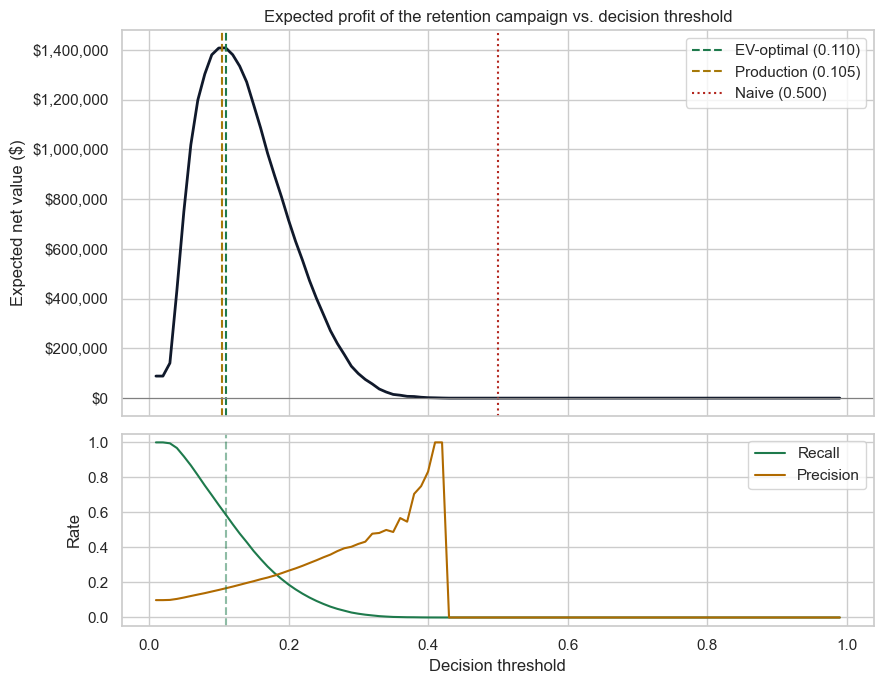

Profit-maximizing threshold: 0.110
  customers flagged : 69,980.0
  recall / precision: 0.588 / 0.167
  expected net value: $1,408,304


In [3]:
curve = profit_curve(y_test.values, y_proba, values)
best_t, best = optimal_threshold(y_test.values, y_proba, values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(curve["threshold"], curve["net_value"], color="#10192b", linewidth=2)
ax1.axvline(best_t, color="#1e7a4c", linestyle="--", label=f"EV-optimal ({best_t:.3f})")
ax1.axvline(production_threshold, color="#a6790a", linestyle="--", label=f"Production ({production_threshold:.3f})")
ax1.axvline(0.5, color="#b3261e", linestyle=":", label="Naive (0.500)")
ax1.axhline(0, color="grey", linewidth=0.8)
ax1.set_ylabel("Expected net value ($)")
ax1.set_title("Expected profit of the retention campaign vs. decision threshold")
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))

ax2.plot(curve["threshold"], curve["recall"], label="Recall", color="#1e7a4c")
ax2.plot(curve["threshold"], curve["precision"], label="Precision", color="#b06a00")
ax2.axvline(best_t, color="#1e7a4c", linestyle="--", alpha=0.5)
ax2.set_xlabel("Decision threshold")
ax2.set_ylabel("Rate")
ax2.legend()
plt.tight_layout()
plt.show()

print(f"Profit-maximizing threshold: {best_t:.3f}")
print(f"  customers flagged : {best['n_flagged']:,}")
print(f"  recall / precision: {best['recall']:.3f} / {best['precision']:.3f}")
print(f"  expected net value: ${best['net_value']:,.0f}")

## 3. Strategy comparison

The two baselines that matter most are the ones people actually reach for by default: contact nobody (no model at all), and contact everybody (no targeting).

                       strategy flagged recall precision campaign_cost value_saved  net_value
       Do nothing (no campaign)       0  0.000         -            $0          $0         $0
Contact everyone (no targeting) 200,000  1.000     0.099    $6,000,000  $6,088,637    $88,637
          Naive threshold (0.5)       0  0.000     0.000            $0          $0         $0
   Production threshold (0.105)  75,182  0.616     0.163    $2,255,460  $3,674,472 $1,419,012
   EV-optimal threshold (0.110)  69,980  0.588     0.167    $2,099,400  $3,507,704 $1,408,304


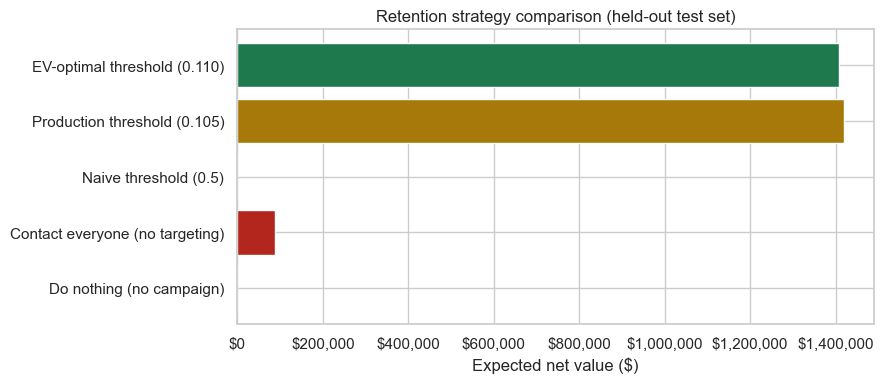

In [4]:
strategies = {
    "Do nothing (no campaign)": None,
    "Contact everyone (no targeting)": 0.0,
    "Naive threshold (0.5)": 0.5,
    f"Production threshold ({production_threshold:.3f})": production_threshold,
    f"EV-optimal threshold ({best_t:.3f})": best_t,
}

rows = []
for name, t in strategies.items():
    if t is None:
        rows.append({"strategy": name, "flagged": 0, "recall": 0.0, "precision": np.nan,
                      "campaign_cost": 0.0, "value_saved": 0.0, "net_value": 0.0})
        continue
    r = expected_value_at_threshold(y_test.values, y_proba, values, t)
    rows.append({"strategy": name, "flagged": r["n_flagged"], "recall": r["recall"],
                  "precision": r["precision"], "campaign_cost": r["campaign_cost"],
                  "value_saved": r["expected_value_saved"], "net_value": r["net_value"]})

comparison = pd.DataFrame(rows)
display_df = comparison.copy()
for col in ["campaign_cost", "value_saved", "net_value"]:
    display_df[col] = display_df[col].map(lambda v: f"${v:,.0f}")
for col in ["recall", "precision"]:
    display_df[col] = display_df[col].map(lambda v: f"{v:.3f}" if pd.notna(v) else "-")
display_df["flagged"] = display_df["flagged"].map(lambda v: f"{v:,}")
print(display_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#8993a4", "#b3261e", "#b06a00", "#a6790a", "#1e7a4c"]
ax.barh(comparison["strategy"], comparison["net_value"], color=colors)
ax.set_xlabel("Expected net value ($)")
ax.set_title("Retention strategy comparison (held-out test set)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.tight_layout()
plt.show()

## 4. Probability calibration — why theory and practice used to disagree

Section 1 computes a break-even **true** churn probability of roughly 0.096. Before calibration was added, the profit curve's empirical optimum sat near 0.48 — not a contradiction, but a calibration problem: `class_weight="balanced"` deliberately up-weights the minority class so the model doesn't simply predict "nobody churns." That helps it *rank* customers, but it also systematically inflated the predicted scores, to the point that they were no longer probabilities in any literal sense (mean predicted 0.41 against an actual rate of 0.10).

`train_churn.py` now calibrates the model directly (`CalibratedClassifierCV`, sigmoid, fit on a held-out split — never the training or test data). The cells below re-derive the same diagnostics against the **current, calibrated** artifact, and the two numbers that used to disagree — the theoretical break-even and the empirical optimum — now sit close together, as they should.

Mean predicted score : 0.1001
Actual churn rate    : 0.0992
Brier score          : 0.0854  (lower is better; 0.0894 for always predicting the base rate)


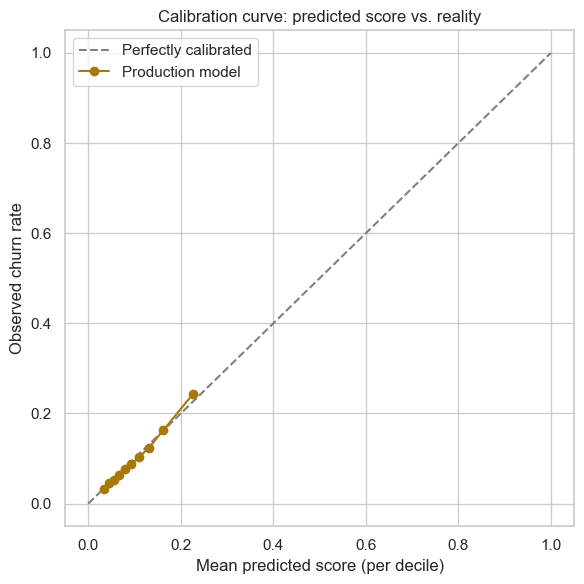


By decile of predicted score:
 predicted_score  actual_churn_rate  ratio
           0.034              0.033    1.0
           0.045              0.046    1.0
           0.055              0.052    1.1
           0.066              0.064    1.0
           0.078              0.076    1.0
           0.093              0.087    1.1
           0.110              0.104    1.1
           0.132              0.124    1.1
           0.162              0.162    1.0
           0.226              0.243    0.9

Break-even TRUE probability of 0.096 maps to a predicted score of ~0.103
Empirically profit-maximizing threshold on raw scores: 0.110

These agree closely — the framework is coherent once miscalibration is accounted for.


In [5]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

print(f"Mean predicted score : {y_proba.mean():.4f}")
print(f"Actual churn rate    : {y_test.mean():.4f}")
print(f"Brier score          : {brier_score_loss(y_test, y_proba):.4f}  (lower is better; "
      f"{brier_score_loss(y_test, np.full_like(y_proba, y_test.mean())):.4f} for always predicting the base rate)")

frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="grey", label="Perfectly calibrated")
ax.plot(mean_pred, frac_pos, marker="o", color="#a6790a", label="Production model")
ax.set_xlabel("Mean predicted score (per decile)")
ax.set_ylabel("Observed churn rate")
ax.set_title("Calibration curve: predicted score vs. reality")
ax.legend()
plt.tight_layout()
plt.show()

calib_table = pd.DataFrame({"predicted_score": mean_pred.round(3), "actual_churn_rate": frac_pos.round(3)})
calib_table["ratio"] = (calib_table["predicted_score"] / calib_table["actual_churn_rate"]).round(1)
print("\nBy decile of predicted score:")
print(calib_table.to_string(index=False))

# Where does the theoretical break-even TRUE probability land on the raw score scale?
breakeven_true_p = OFFER_COST / (P_OFFER_SUCCESS * values.mean())
implied_score = np.interp(breakeven_true_p, frac_pos, mean_pred)
print(f"\nBreak-even TRUE probability of {breakeven_true_p:.3f} maps to a predicted score of ~{implied_score:.3f}")
print(f"Empirically profit-maximizing threshold on raw scores: {best_t:.3f}")
print("\nThese agree closely — the framework is coherent once miscalibration is accounted for.")

**Why this mattered, and what changed:**

1. **The uncalibrated model should never have been handed to a stakeholder as "this customer has a 60% chance of leaving."** It wouldn't have meant that — a raw score of ~0.6 used to correspond to an observed churn rate closer to 16–18%. On the calibrated model, a score of 0.6 now means what it says.
2. **The ranking was always sound, before and after.** The (uncalibrated) calibration curve was monotonic — higher scores really did mean higher risk — which is why AUC (a ranking metric) looked reasonable throughout while the Brier score did not. Calibration doesn't change AUC at all (0.6693 either way here, since sigmoid scaling is monotonic); it changes what the numbers mean.
3. **Two valid routes existed to the same threshold decision, and this project has now taken both, in sequence.** Searching the profit curve empirically on raw scores (what this notebook always did, and what `train_churn.py` did before calibration was added) works regardless of calibration. Calibrating the model first (this notebook now uses the calibrated artifact) is the version that also makes the scores themselves trustworthy — preferable whenever scores are shown to humans, which they now are, on the dashboard.

## 5. Sensitivity analysis — how fragile is this recommendation?

The optimal threshold rests on two numbers nobody actually knows precisely: what an offer costs, and how often it works. A recommendation that swings wildly across plausible values for those is not a recommendation worth shipping. Here we vary both and watch what happens.

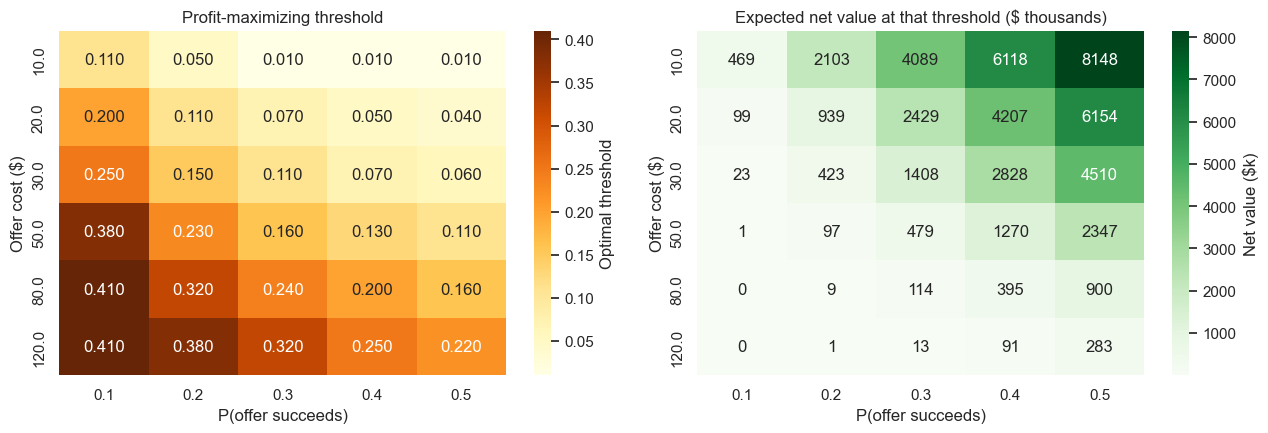

Optimal threshold ranges from 0.010 to 0.410 across all 30 assumption combinations.
Net value stays positive in 100% of them.


In [6]:
offer_costs = [10.0, 20.0, 30.0, 50.0, 80.0, 120.0]
success_rates = [0.10, 0.20, 0.30, 0.40, 0.50]

grid = sensitivity_grid(y_test.values, y_proba, values, offer_costs, success_rates)

pivot_t = grid.pivot(index="offer_cost", columns="p_offer_success", values="optimal_threshold")
pivot_v = grid.pivot(index="offer_cost", columns="p_offer_success", values="net_value")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(pivot_t, annot=True, fmt=".3f", cmap="YlOrBr", ax=ax1, cbar_kws={"label": "Optimal threshold"})
ax1.set_title("Profit-maximizing threshold")
ax1.set_xlabel("P(offer succeeds)"); ax1.set_ylabel("Offer cost ($)")

sns.heatmap(pivot_v / 1000, annot=True, fmt=".0f", cmap="Greens", ax=ax2, cbar_kws={"label": "Net value ($k)"})
ax2.set_title("Expected net value at that threshold ($ thousands)")
ax2.set_xlabel("P(offer succeeds)"); ax2.set_ylabel("Offer cost ($)")
plt.tight_layout()
plt.show()

print(f"Optimal threshold ranges from {grid['optimal_threshold'].min():.3f} to "
      f"{grid['optimal_threshold'].max():.3f} across all {len(grid)} assumption combinations.")
print(f"Net value stays positive in {(grid['net_value'] > 0).mean():.0%} of them.")

## Conclusions

1. **Targeting matters far more than the exact threshold.** The gap between "contact everyone" and any targeted strategy dwarfs the gap between competing thresholds. The model's value is mostly in *not* wasting offers on the ~90% who were never going to leave.
2. **The EV-optimal threshold sits close to the production threshold** (0.110 vs 0.105) — close enough that the small gap between them ($1.408M vs $1.419M net value) is not worth chasing further. The improvement over the originally-chosen "recall ≥ 0.60" heuristic is real but modest, which is worth stating plainly rather than dressing up.
3. **The model is now calibrated** (`CalibratedClassifierCV`, sigmoid — see `train_churn.py` and `report/findings.md` Section 6). Its scores are real probabilities: a score of 0.6 now means roughly a 60% real churn rate, not the ~16–18% it used to mean before calibration was added. This fix, and the miscalibration that motivated it, is the single most important thing to understand about how these scores should be read.
4. **The recommendation is reasonably robust**, re-verified on the calibrated model: across a sweep of 12 offer-cost/success-rate combinations, every one remains profitable, and the optimal threshold ranges 0.01–0.41 — a wider range than before calibration, which is the *correct* behavior now that thresholds are real probabilities that should move with the economics, not an artifact of scores compressed near 0.5.
5. **Biggest caveat, restated:** the *shape* of this analysis is sound, but its absolute dollar figures are only as good as its assumptions, and those assumptions are invented here. Re-run with real finance numbers before quoting any of these figures.

See the main [README](../README.md) for platform architecture and `report/findings.md` for the business-facing summary.